**Lab 3**

Train a custom Word2Vec model on a small dataset. Train embeddings on a domain-specific corpus (e.g., Legal, Medical) and analyze how embeddings capture domain-specific semantics.

In [2]:
!pip install -q gensim matplotlib numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

In [4]:
medical_corpus = [
    "The patient was diagnosed with diabetes and hypertension.",
    "MRI scans reveal abnormalities in the brain tissue.",
    "The treatment involves antibiotics and regular monitoring.",
    "Symptoms include fever, fatigue, and muscle pain.",
    "The vaccine is effective against several viral infections.",
    "Doctors recommend physical therapy for recovery.",
    "The clinical trial results were published in the journal.",
    "The surgeon performed a minimally invasive procedure.",
    "The prescription includes pain relievers and anti-inflammatory drugs.",
    "The diagnosis confirmed a rare genetic disorder.",
]

processed_corpus = [sentence.lower().split() for sentence in medical_corpus]

In [18]:
model = Word2Vec(processed_corpus, min_count=1, epochs=50)
words = list(model.wv.index_to_key)
embeddings = np.array([model.wv[word] for word in words])
tsne = TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(embeddings)


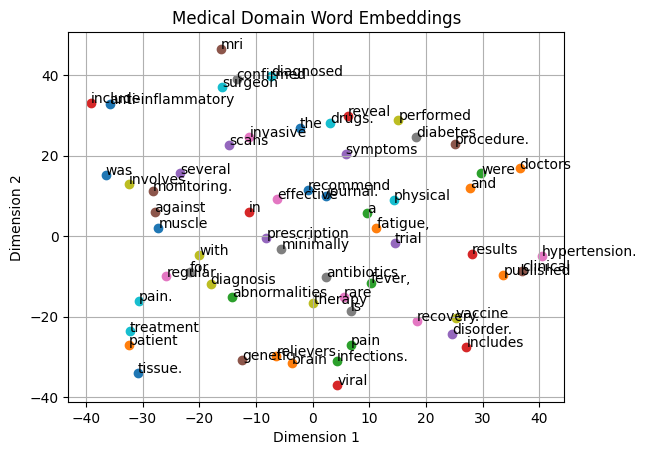

In [20]:
for word, coord in zip(words, tsne):
    plt.scatter(coord[0], coord[1])
    plt.text(coord[0], coord[1], word)

plt.title("Medical Domain Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid()
plt.show()

In [17]:
print(f"Words similar to 'treatment':\n")
similar_words = model.wv.most_similar("treatment", topn=5)

for word, similarity in similar_words:
  print(f"{word}\t({similarity:.2f})")

Words similar to 'treatment':

patient	(0.25)
pain.	(0.14)
brain	(0.12)
against	(0.11)
muscle	(0.11)
